# ぼやけスコアの分布確認

`add_blur_scores.py` で `blur_scores_val` / `blur_scores_mean` を付与済みのパッチh5群を対象に、
スコアの分布を確認する。`build_dataset.py` の `--threshold` / `--threshold_percentile` を決める際の参考にする。

In [23]:
import sys
sys.path.append("..")

from pathlib import Path

import h5py
import pandas as pd
import matplotlib.pyplot as plt

from src import blur
from src.patch_source import iter_h5_paths, slide_stem

In [24]:
h5_dir = Path("../results/trident/20x_256px_0px_overlap/patches")
h5_paths = iter_h5_paths(h5_dir)
print(f"{len(h5_paths)} h5 files found")

1000 h5 files found


## スコアをDataFrameに集約

スライドごと・パッチごとに `blur_scores_val` / `blur_scores_mean` を1行ずつ持つ表にする。
`add_blur_scores.py` 未実行のh5(いずれかのmetricが無い)はスキップする。

In [25]:
rows = []
skipped = []
for p in h5_paths:
    with h5py.File(p, "r") as f:
        if not all(name in f for name in blur.METRICS):
            skipped.append(p)
            continue
        n = f["coords"].shape[0]
        data = {"slide_id": [slide_stem(p)] * n}
        for name in blur.METRICS:
            data[name] = f[name][:]
        rows.append(pd.DataFrame(data))

df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
print(f"{len(df)} patches from {df['slide_id'].nunique() if len(df) else 0} slides")
if skipped:
    print(f"skipped {len(skipped)} h5 files (blur scores not computed yet):")
    for p in skipped[:5]:
        print(f"  - {p}")

14129007 patches from 1000 slides


## 全体の要約統計量

In [26]:
df[list(blur.METRICS)].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

,blur_scores_val,blur_scores_mean
count,1.412901e+07,1.412901e+07
mean,1.181146e+03,6.450349e+01
std,6.306304e+02,2.171196e+01
min,0.000000e+00,0.000000e+00
1%,5.923893e+00,2.273241e+00
5%,2.229730e+02,2.266639e+01
25%,7.144596e+02,5.220962e+01
50%,1.138480e+03,6.703059e+01
75%,1.582273e+03,7.922690e+01
95%,2.307237e+03,9.618866e+01


## ヒストグラム(全パッチ)

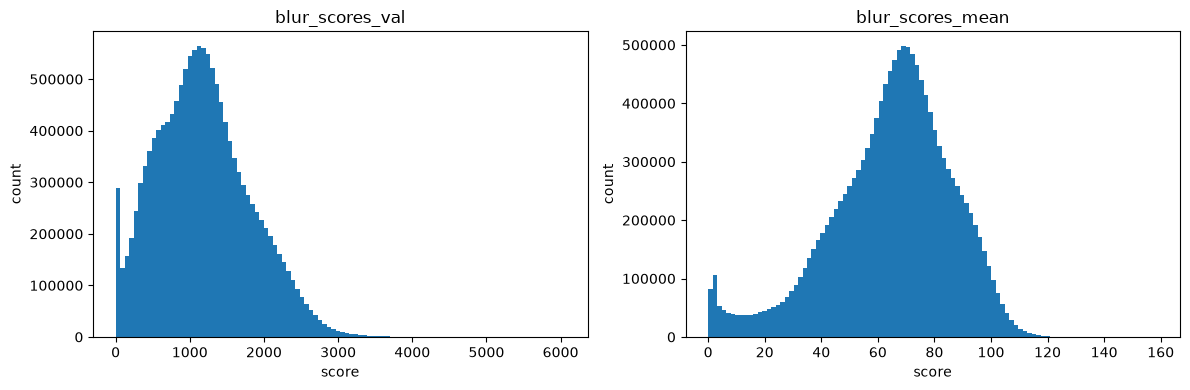

In [27]:
fig, axes = plt.subplots(1, len(blur.METRICS), figsize=(6 * len(blur.METRICS), 4))
for ax, name in zip(axes, blur.METRICS):
    ax.hist(df[name], bins=100)
    ax.set_title(name)
    ax.set_xlabel("score")
    ax.set_ylabel("count")
fig.tight_layout()

## スライドごとの平均スコア(スキャナ差・スライド差の確認用)

`--threshold_percentile` はスライドごとの分位点で閾値を決めるため、スライド間でスコアの
スケールがどれくらいばらついているかをここで確認する。

In [28]:
per_slide = df.groupby("slide_id")[list(blur.METRICS)].mean().sort_values(list(blur.METRICS)[0])
per_slide

,blur_scores_val,blur_scores_mean
slide_id,,
44813,188.482040,23.927740
58738,251.997559,26.334621
44132,261.276459,30.302181
13729,288.329590,31.962099
58723,293.949829,28.250034
...,...,...
11735,2567.391113,93.350510
71325,2584.672363,97.057190
12861,2595.490723,98.164413


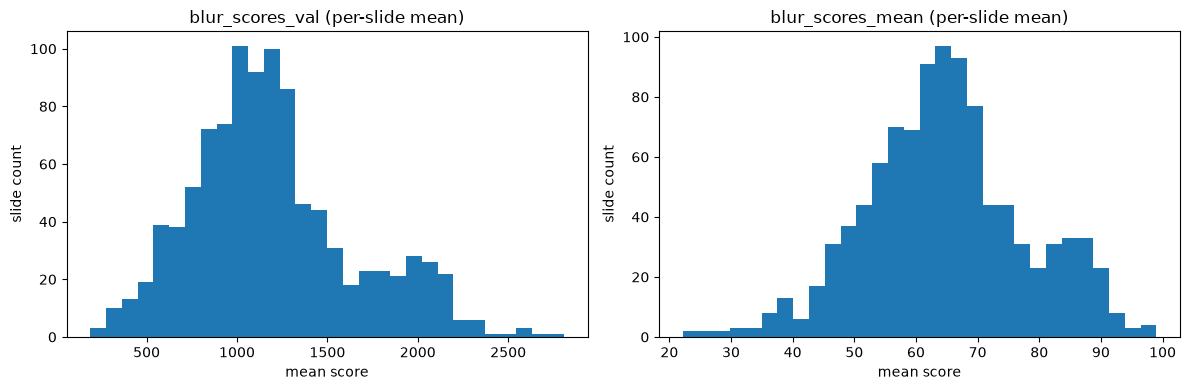

In [29]:
fig, axes = plt.subplots(1, len(blur.METRICS), figsize=(6 * len(blur.METRICS), 4))
for ax, name in zip(axes, blur.METRICS):
    ax.hist(per_slide[name], bins=30)
    ax.set_title(f"{name} (per-slide mean)")
    ax.set_xlabel("mean score")
    ax.set_ylabel("slide count")
fig.tight_layout()